# Statistical Tests

Notebook for statistical analysis of the current `training_runs` layout.

This version does **not** use ensemble predictions.
Instead, it treats each retained `inner_model_k` as an independent replicate.
Across outer folds, predictions from the same `seed x inner_model_k` are stitched together into one full out-of-fold prediction vector over patients. No averaging is done across inner models: each retained `inner_model_k` is treated as its own statistical replicate.

Configuration in the first code cell:
- `DATASET_NAME`
- `LABEL_NAME`
- `TRAIN_MISSING_LOCATION`
- bootstrap settings

Expected results path:
- `results/<DATASET_NAME>_<LABEL_NAME>/training_runs`

The notebook implements three levels of analysis:

1. **Per-model uncertainty from independent inner-model replicates**
- compute AUC for every `seed x inner_model_k` replicate
- summarize mean AUC and bootstrap `95% CI` across replicate AUCs

2. **Local pairwise model comparison per missingness cell**
- each model contributes its 25 paired replicate AUCs (`5 seeds x 5 inner models`)
- compare all model pairs with paired Wilcoxon signed-rank tests
- apply FDR (Benjamini-Hochberg) correction within each missingness cell
- keep only statistically significant pairs for the level 2 plot

3. **Global comparison across conditions**
- Friedman test across complete missingness conditions using condition-level mean AUC
- pairwise Wilcoxon signed-rank tests with Holm correction
- average ranks across conditions

Outputs are saved under:
- `analysis/statistical_tests_outputs/<DATASET_NAME>_<LABEL_NAME>/<TRAIN_MISSING_LOCATION>/`


In [10]:
from pathlib import Path

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == 'analysis' else cwd

DATASET_NAME = 'MIMM'
LABEL_NAME = 'OS_9_label'
TRAIN_MISSING_LOCATION = 'GLOBAL'

N_BOOTSTRAP = 2000
BOOTSTRAP_CONFIDENCE = 0.95
BOOTSTRAP_RANDOM_SEED = 42

RESULTS_TAG = f'{DATASET_NAME}_{LABEL_NAME}' if str(LABEL_NAME).strip() else DATASET_NAME
RESULTS_ROOT = PROJECT_ROOT / 'results' / RESULTS_TAG / 'training_runs'
if not RESULTS_ROOT.exists():
    raise FileNotFoundError(
        f'Results root does not exist for dataset={DATASET_NAME!r}, label={LABEL_NAME!r}: {RESULTS_ROOT}'
    )
if not RESULTS_ROOT.is_dir():
    raise NotADirectoryError(f'Expected a directory at: {RESULTS_ROOT}')

OUTPUT_DIR = (
    (cwd / 'statistical_tests_outputs') if cwd.name == 'analysis' else (cwd / 'analysis' / 'statistical_tests_outputs')
) / RESULTS_TAG / TRAIN_MISSING_LOCATION.lower()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_ROOT


PosixPath('/Users/marcalbesa/Desktop/TFM/git_exp/methods/results/MIMM_OS_9_label/training_runs')

In [11]:
import itertools
import math
import re
import warnings
import zlib

import numpy as np
import pandas as pd
from scipy.stats import friedmanchisquare, rankdata, wilcoxon
from sklearn.metrics import roc_auc_score

try:
    import matplotlib.pyplot as plt
    from matplotlib.colors import ListedColormap
    from matplotlib.patches import Patch
    HAVE_MPL = True
except ImportError:
    plt = None
    ListedColormap = None
    Patch = None
    HAVE_MPL = False

DISPLAY_NAME_MAP = {
    'ZERO_MLP': 'ZI_MLP',
    'KNN_MLP': 'KNN_MLP',
    'VAE_MLP': 'VAE_MLP',
    'PAM': 'pAM',
    'DIPAM': 'MLPDiPAM',
    'DI_PAM': 'MLPDiPAM',
    'MLPDIPAM': 'MLPDiPAM',
    'MLP_DIPAM': 'MLPDiPAM',
    'PAMDIPAM': 'PAMDiPAM',
    'PAM_DIPAM': 'PAMDiPAM',
    'HEALNET': 'HealNet',
    'SMILE': 'SMILe',
}
INNER_MODEL_PROB_RE = re.compile(r'^inner_model_(\d+)_prob$')


def _normalize_model_label(name: str) -> str:
    raw = str(name).strip()
    if '_retrain' in raw:
        raw = raw.split('_retrain', 1)[0]
    compact = raw.replace('-', '_').upper()
    return DISPLAY_NAME_MAP.get(compact, raw)


def _stable_seed(*parts, base_seed=0):
    text = '|'.join(str(part) for part in parts)
    return (zlib.crc32(text.encode('utf-8')) + int(base_seed)) % (2**32 - 1)


def list_model_sources(results_root: Path, dataset_name: str, train_missing_location: str):
    sources = []
    for run_dir in sorted(p for p in results_root.iterdir() if p.is_dir() and not p.name.startswith('.')):
        model_label = _normalize_model_label(run_dir.name)
        candidate_dirs = [p for p in run_dir.iterdir() if p.is_dir() and not p.name.startswith('.')]
        train_missing_dir = None
        for candidate_dir in candidate_dirs:
            probe = candidate_dir / dataset_name.upper() / 'TRAIN_MISSING' / train_missing_location.upper()
            if probe.exists():
                train_missing_dir = probe
                break
        if train_missing_dir is not None:
            sources.append({
                'model_name': model_label,
                'run_dir': run_dir,
                'train_missing_dir': train_missing_dir,
            })
    return sources


def _parse_seed_from_path(path: Path):
    for parent in path.parents:
        if parent.name.startswith('seed_'):
            try:
                return int(parent.name.replace('seed_', ''))
            except ValueError:
                return parent.name.replace('seed_', '')
    return np.nan


def _list_inner_model_prob_cols(df: pd.DataFrame):
    cols = []
    for col in df.columns:
        match = INNER_MODEL_PROB_RE.match(str(col))
        if match:
            cols.append((int(match.group(1)), col))
    cols.sort(key=lambda item: item[0])
    return cols


def normalize_prediction_df(pred_df: pd.DataFrame):
    out = pred_df.copy()
    required_cols = [
        'model_name',
        'patient',
        'train_missing_prop',
        'test_missing_prop',
        'y_true',
    ]
    missing_cols = [col for col in required_cols if col not in out.columns]
    if missing_cols:
        raise ValueError(f'Missing required prediction columns: {missing_cols}')

    inner_prob_cols = _list_inner_model_prob_cols(out)
    if not inner_prob_cols:
        raise ValueError('No inner_model_*_prob columns found in prediction dataframe.')

    if 'outer_eval_target' in out.columns:
        out = out.loc[out['outer_eval_target'].astype(str) == 'test_outer'].copy()

    out['model_name'] = out['model_name'].astype(str)
    out['patient'] = out['patient'].astype(str)
    out['train_missing_prop'] = out['train_missing_prop'].astype(float)
    out['test_missing_prop'] = out['test_missing_prop'].astype(float)
    out['y_true'] = out['y_true'].astype(int)
    if 'seed' in out.columns:
        out['seed'] = out['seed']
    else:
        out['seed'] = np.nan
    if 'outer_fold' not in out.columns:
        out['outer_fold'] = np.nan
    return out.reset_index(drop=True)


def load_all_test_predictions(results_root: Path, dataset_name: str, train_missing_location: str):
    frames = []
    for source in list_model_sources(results_root, dataset_name, train_missing_location):
        for path in sorted(source['train_missing_dir'].rglob('test_predictions.csv')):
            df = pd.read_csv(path)
            if df.empty:
                continue
            if 'seed' not in df.columns:
                df['seed'] = _parse_seed_from_path(path)
            df['model_name'] = source['model_name']
            df['source_file'] = str(path)
            frames.append(df)

    if not frames:
        return pd.DataFrame()
    return normalize_prediction_df(pd.concat(frames, ignore_index=True))


def expand_inner_model_predictions(pred_df: pd.DataFrame):
    if pred_df.empty:
        return pd.DataFrame()

    prob_cols = _list_inner_model_prob_cols(pred_df)
    rows = []
    base_cols = [
        'model_name', 'patient', 'train_missing_prop', 'test_missing_prop', 'y_true',
        'seed', 'outer_fold'
    ]
    for member_idx, prob_col in prob_cols:
        sub_df = pred_df[base_cols + [prob_col]].copy()
        sub_df = sub_df.rename(columns={prob_col: 'member_prob'})
        sub_df['inner_model_idx'] = int(member_idx)
        sub_df['replicate_id'] = (
            sub_df['seed'].astype(str) + '|inner_' + sub_df['inner_model_idx'].astype(str)
        )
        rows.append(sub_df)

    long_df = pd.concat(rows, ignore_index=True)
    long_df['member_prob'] = long_df['member_prob'].astype(float)
    long_df = long_df.dropna(subset=['member_prob']).reset_index(drop=True)
    return long_df


def aggregate_member_patient_predictions(member_pred_df: pd.DataFrame):
    if member_pred_df.empty:
        return pd.DataFrame()

    group_cols = [
        'model_name', 'train_missing_prop', 'test_missing_prop', 'seed',
        'inner_model_idx', 'replicate_id', 'patient', 'y_true'
    ]
    counts_df = (
        member_pred_df
        .groupby(group_cols, as_index=False)
        .size()
        .rename(columns={'size': 'n_prediction_rows'})
    )
    duplicated_df = counts_df.loc[counts_df['n_prediction_rows'] > 1].copy()
    if not duplicated_df.empty:
        sample_rows = duplicated_df.head(10).to_dict(orient='records')
        raise ValueError(
            'Found duplicated predictions for the same seed x inner_model x patient x missingness cell. '
            'This notebook does not collapse them into a single predictor. Sample duplicated groups: '
            f'{sample_rows}'
        )

    out_df = (
        member_pred_df[group_cols + ['member_prob']]
        .copy()
        .sort_values([
            'model_name', 'train_missing_prop', 'test_missing_prop', 'seed',
            'inner_model_idx', 'patient'
        ])
        .reset_index(drop=True)
    )
    out_df['n_prediction_rows'] = 1
    return out_df


def safe_auc(y_true, y_prob):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(roc_auc_score(y_true, y_prob))


def bootstrap_mean_ci(values, n_bootstrap=2000, confidence=0.95, random_seed=42):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return {
            'mean': np.nan,
            'ci_lower': np.nan,
            'ci_upper': np.nan,
            'ci_half_width': np.nan,
            'n_bootstrap_valid': 0,
        }
    observed_mean = float(np.mean(values))
    if values.size == 1:
        return {
            'mean': observed_mean,
            'ci_lower': observed_mean,
            'ci_upper': observed_mean,
            'ci_half_width': 0.0,
            'n_bootstrap_valid': 1,
        }

    rng = np.random.default_rng(int(random_seed))
    alpha = 1.0 - float(confidence)
    samples = []
    n = values.size
    for _ in range(int(n_bootstrap)):
        idx = rng.integers(0, n, size=n)
        samples.append(float(np.mean(values[idx])))
    arr = np.asarray(samples, dtype=float)
    ci_lower, ci_upper = np.quantile(arr, [alpha / 2.0, 1.0 - (alpha / 2.0)])
    return {
        'mean': observed_mean,
        'ci_lower': float(ci_lower),
        'ci_upper': float(ci_upper),
        'ci_half_width': float((ci_upper - ci_lower) / 2.0),
        'n_bootstrap_valid': int(arr.size),
    }


def bootstrap_paired_mean_difference(values_a, values_b, n_bootstrap=2000, confidence=0.95, random_seed=42):
    values_a = np.asarray(values_a, dtype=float)
    values_b = np.asarray(values_b, dtype=float)
    deltas = values_a - values_b
    deltas = deltas[np.isfinite(deltas)]
    if deltas.size == 0:
        return {
            'delta_mean': np.nan,
            'ci_lower': np.nan,
            'ci_upper': np.nan,
            'n_bootstrap_valid': 0,
        }
    observed = float(np.mean(deltas))
    if deltas.size == 1:
        return {
            'delta_mean': observed,
            'ci_lower': observed,
            'ci_upper': observed,
            'n_bootstrap_valid': 1,
        }

    rng = np.random.default_rng(int(random_seed))
    alpha = 1.0 - float(confidence)
    samples = []
    n = deltas.size
    for _ in range(int(n_bootstrap)):
        idx = rng.integers(0, n, size=n)
        samples.append(float(np.mean(deltas[idx])))
    arr = np.asarray(samples, dtype=float)
    ci_lower, ci_upper = np.quantile(arr, [alpha / 2.0, 1.0 - (alpha / 2.0)])
    return {
        'delta_mean': observed,
        'ci_lower': float(ci_lower),
        'ci_upper': float(ci_upper),
        'n_bootstrap_valid': int(arr.size),
    }


def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    adjusted = np.full(p_values.shape, np.nan, dtype=float)
    finite_mask = np.isfinite(p_values)
    finite_idx = np.where(finite_mask)[0]
    if finite_idx.size == 0:
        return adjusted

    order = finite_idx[np.argsort(p_values[finite_idx])]
    m = len(order)
    running_max = 0.0
    for rank, idx in enumerate(order, start=1):
        adj = (m - rank + 1) * p_values[idx]
        running_max = max(running_max, adj)
        adjusted[idx] = min(running_max, 1.0)
    return adjusted


def fdr_bh_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    adjusted = np.full(p_values.shape, np.nan, dtype=float)
    finite_mask = np.isfinite(p_values)
    finite_idx = np.where(finite_mask)[0]
    if finite_idx.size == 0:
        return adjusted

    order = finite_idx[np.argsort(p_values[finite_idx])]
    m = len(order)
    prev = 1.0
    for rank_from_end, idx in enumerate(order[::-1], start=1):
        rank = m - rank_from_end + 1
        adj = (m / rank) * p_values[idx]
        prev = min(prev, adj)
        adjusted[idx] = min(prev, 1.0)
    return adjusted


def compute_replicate_auc_table(member_patient_df: pd.DataFrame):
    if member_patient_df.empty:
        return pd.DataFrame()
    rows = []
    group_cols = [
        'model_name', 'train_missing_prop', 'test_missing_prop', 'seed',
        'inner_model_idx', 'replicate_id'
    ]
    for key, group_df in member_patient_df.groupby(group_cols, sort=True):
        model_name, train_prop, test_prop, seed, inner_idx, replicate_id = key
        auc_val = safe_auc(group_df['y_true'].to_numpy(), group_df['member_prob'].to_numpy())
        rows.append({
            'model_name': model_name,
            'train_missing_prop': float(train_prop),
            'test_missing_prop': float(test_prop),
            'seed': seed,
            'inner_model_idx': int(inner_idx),
            'replicate_id': str(replicate_id),
            'n_patients': int(group_df['patient'].nunique()),
            'auc': auc_val,
        })
    return pd.DataFrame(rows).sort_values([
        'model_name', 'train_missing_prop', 'test_missing_prop', 'seed', 'inner_model_idx'
    ]).reset_index(drop=True)


def compute_level1_summary(replicate_auc_df: pd.DataFrame, n_bootstrap=2000, confidence=0.95, random_seed=42):
    rows = []
    for (model_name, train_prop, test_prop), group_df in replicate_auc_df.groupby(['model_name', 'train_missing_prop', 'test_missing_prop'], sort=True):
        stats = bootstrap_mean_ci(
            group_df['auc'].to_numpy(dtype=float),
            n_bootstrap=n_bootstrap,
            confidence=confidence,
            random_seed=_stable_seed(model_name, train_prop, test_prop, base_seed=random_seed),
        )
        rows.append({
            'model_name': model_name,
            'train_missing_prop': float(train_prop),
            'test_missing_prop': float(test_prop),
            'n_replicates': int(group_df['auc'].notna().sum()),
            'mean_auc': stats['mean'],
            'ci_lower': stats['ci_lower'],
            'ci_upper': stats['ci_upper'],
            'ci_half_width': stats['ci_half_width'],
            'n_bootstrap_valid': stats['n_bootstrap_valid'],
            'std_auc': float(group_df['auc'].std(ddof=1)) if group_df['auc'].notna().sum() > 1 else 0.0,
        })
    return pd.DataFrame(rows).sort_values(['model_name', 'train_missing_prop', 'test_missing_prop']).reset_index(drop=True)


def build_paired_replicate_auc_df(replicate_auc_df: pd.DataFrame, model_a: str, model_b: str, train_prop: float, test_prop: float):
    cond_mask = (
        np.isclose(replicate_auc_df['train_missing_prop'], float(train_prop)) &
        np.isclose(replicate_auc_df['test_missing_prop'], float(test_prop))
    )
    cond_df = replicate_auc_df.loc[cond_mask].copy()
    a_df = cond_df.loc[cond_df['model_name'] == model_a, ['seed', 'inner_model_idx', 'replicate_id', 'auc']].rename(columns={'auc': 'auc_a'})
    b_df = cond_df.loc[cond_df['model_name'] == model_b, ['seed', 'inner_model_idx', 'replicate_id', 'auc']].rename(columns={'auc': 'auc_b'})
    merged = a_df.merge(b_df, on=['seed', 'inner_model_idx', 'replicate_id'], how='inner')
    if merged.empty:
        raise ValueError(
            f'No overlapping replicate AUCs for {model_a!r} and {model_b!r} at train={train_prop}, test={test_prop}.'
        )
    return merged.sort_values(['seed', 'inner_model_idx']).reset_index(drop=True)


def compute_level2_pairwise_tests(level1_df: pd.DataFrame, replicate_auc_df: pd.DataFrame):
    rows = []
    for (train_prop, test_prop), cond_df in level1_df.groupby(['train_missing_prop', 'test_missing_prop'], sort=True):
        cond_df = cond_df.dropna(subset=['mean_auc']).sort_values(['mean_auc', 'model_name'], ascending=[False, True]).reset_index(drop=True)
        model_names = cond_df['model_name'].tolist()
        if len(model_names) < 2:
            continue

        mean_auc_lookup = cond_df.set_index('model_name')['mean_auc'].to_dict()
        cell_rows = []
        for model_a, model_b in itertools.combinations(model_names, 2):
            paired_df = build_paired_replicate_auc_df(
                replicate_auc_df=replicate_auc_df,
                model_a=model_a,
                model_b=model_b,
                train_prop=train_prop,
                test_prop=test_prop,
            )

            mean_a = float(mean_auc_lookup[model_a])
            mean_b = float(mean_auc_lookup[model_b])
            if mean_a >= mean_b:
                winner_model, loser_model = model_a, model_b
                winner_mean_auc, loser_mean_auc = mean_a, mean_b
                winner_values = paired_df['auc_a'].to_numpy(dtype=float)
                loser_values = paired_df['auc_b'].to_numpy(dtype=float)
            else:
                winner_model, loser_model = model_b, model_a
                winner_mean_auc, loser_mean_auc = mean_b, mean_a
                winner_values = paired_df['auc_b'].to_numpy(dtype=float)
                loser_values = paired_df['auc_a'].to_numpy(dtype=float)

            delta_values = winner_values - loser_values
            delta_mean_auc = float(np.mean(delta_values))
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter('ignore', RuntimeWarning)
                    w_stat, p_value = wilcoxon(
                        winner_values,
                        loser_values,
                        zero_method='wilcox',
                        alternative='two-sided',
                        method='auto',
                    )
            except ValueError:
                w_stat, p_value = np.nan, 1.0

            cell_rows.append({
                'train_missing_prop': float(train_prop),
                'test_missing_prop': float(test_prop),
                'model_a': str(model_a),
                'model_b': str(model_b),
                'winner_model': str(winner_model),
                'loser_model': str(loser_model),
                'winner_mean_auc': float(winner_mean_auc),
                'loser_mean_auc': float(loser_mean_auc),
                'delta_mean_auc': delta_mean_auc,
                'wilcoxon_statistic': float(w_stat) if np.isfinite(w_stat) else np.nan,
                'p_value': float(p_value),
                'n_replicates': int(len(paired_df)),
            })

        cell_df = pd.DataFrame(cell_rows)
        if not cell_df.empty:
            cell_df['p_value_fdr'] = fdr_bh_adjust(cell_df['p_value'].to_numpy())
            cell_df['significant_fdr_0p05'] = cell_df['p_value_fdr'] < 0.05
            cell_df['n_pairs_tested_in_cell'] = int(len(cell_df))
            rows.append(cell_df)

    if not rows:
        empty_cols = [
            'train_missing_prop', 'test_missing_prop', 'model_a', 'model_b', 'winner_model', 'loser_model',
            'winner_mean_auc', 'loser_mean_auc', 'delta_mean_auc', 'wilcoxon_statistic', 'p_value',
            'p_value_fdr', 'significant_fdr_0p05', 'n_replicates', 'n_pairs_tested_in_cell'
        ]
        return pd.DataFrame(columns=empty_cols)

    out = pd.concat(rows, ignore_index=True)
    return out.sort_values([
        'train_missing_prop', 'test_missing_prop', 'p_value_fdr', 'delta_mean_auc', 'winner_model', 'loser_model'
    ], ascending=[True, True, True, False, True, True]).reset_index(drop=True)


def select_level2_significant_plot_pairs(level2_pairwise_df: pd.DataFrame):
    if level2_pairwise_df.empty:
        return pd.DataFrame(columns=[
            'train_missing_prop', 'test_missing_prop', 'winner_model', 'loser_model',
            'winner_mean_auc', 'loser_mean_auc', 'delta_mean_auc', 'p_value', 'p_value_fdr',
            'wilcoxon_statistic', 'n_replicates', 'n_pairs_tested_in_cell', 'significant_fdr_0p05'
        ])

    sig_df = level2_pairwise_df.loc[level2_pairwise_df['significant_fdr_0p05']].copy()
    if sig_df.empty:
        return sig_df

    sig_df = sig_df.sort_values(
        ['train_missing_prop', 'test_missing_prop', 'p_value_fdr', 'delta_mean_auc', 'winner_mean_auc', 'winner_model', 'loser_model'],
        ascending=[True, True, True, False, False, True, True],
    )
    top_df = (
        sig_df
        .groupby(['train_missing_prop', 'test_missing_prop'], as_index=False, sort=True)
        .first()
    )
    return top_df.sort_values(['train_missing_prop', 'test_missing_prop']).reset_index(drop=True)


def build_global_auc_matrix(level1_df: pd.DataFrame):
    matrix_df = (
        level1_df
        .pivot_table(
            index=['train_missing_prop', 'test_missing_prop'],
            columns='model_name',
            values='mean_auc',
            aggfunc='first',
        )
        .sort_index(axis=0)
        .sort_index(axis=1)
    )
    matrix_df = matrix_df.dropna(axis=0, how='any')
    return matrix_df


def compute_average_ranks(matrix_df: pd.DataFrame):
    if matrix_df.empty:
        return pd.DataFrame(), pd.Series(dtype=float)
    rank_rows = []
    for idx, row in matrix_df.iterrows():
        row_values = row.to_numpy(dtype=float)
        ranks = rankdata(-row_values, method='average')
        rank_rows.append(pd.Series(ranks, index=matrix_df.columns, name=idx))
    ranks_df = pd.DataFrame(rank_rows)
    mean_ranks = ranks_df.mean(axis=0).sort_values()
    return ranks_df, mean_ranks


def run_global_model_tests(matrix_df: pd.DataFrame):
    if matrix_df.empty:
        raise ValueError('Global AUC matrix is empty. Cannot run global tests.')

    ranks_df, mean_ranks = compute_average_ranks(matrix_df)

    if matrix_df.shape[1] >= 3 and matrix_df.shape[0] >= 2:
        friedman_stat, friedman_p = friedmanchisquare(*[matrix_df[col].to_numpy() for col in matrix_df.columns])
    else:
        friedman_stat, friedman_p = np.nan, np.nan

    friedman_summary_df = pd.DataFrame([{
        'n_conditions': int(matrix_df.shape[0]),
        'n_models': int(matrix_df.shape[1]),
        'friedman_statistic': float(friedman_stat) if np.isfinite(friedman_stat) else np.nan,
        'friedman_p_value': float(friedman_p) if np.isfinite(friedman_p) else np.nan,
    }])

    pairwise_rows = []
    model_names = list(matrix_df.columns)
    for model_a, model_b in itertools.combinations(model_names, 2):
        delta = matrix_df[model_a] - matrix_df[model_b]
        try:
            stat, p_value = wilcoxon(delta.to_numpy(dtype=float), zero_method='wilcox', alternative='two-sided', method='auto')
        except ValueError:
            stat, p_value = np.nan, 1.0
        pairwise_rows.append({
            'model_a': model_a,
            'model_b': model_b,
            'n_conditions': int(delta.shape[0]),
            'mean_delta_auc': float(delta.mean()),
            'median_delta_auc': float(delta.median()),
            'wins_model_a': int((delta > 0).sum()),
            'wins_model_b': int((delta < 0).sum()),
            'ties': int((delta == 0).sum()),
            'wilcoxon_statistic': float(stat) if np.isfinite(stat) else np.nan,
            'p_value': float(p_value),
        })
    pairwise_df = pd.DataFrame(pairwise_rows)
    if not pairwise_df.empty:
        pairwise_df['p_value_holm'] = holm_adjust(pairwise_df['p_value'].to_numpy())
        pairwise_df['significant_holm_0p05'] = pairwise_df['p_value_holm'] < 0.05
        pairwise_df = pairwise_df.sort_values(['p_value_holm', 'p_value', 'model_a', 'model_b']).reset_index(drop=True)

    mean_ranks_df = mean_ranks.rename('average_rank').reset_index().rename(columns={'index': 'model_name'})
    return friedman_summary_df, pairwise_df, ranks_df, mean_ranks_df


def _resolve_heatmap_grid(n_models: int):
    n_models = max(int(n_models), 1)
    if n_models <= 4:
        return 1, n_models
    if n_models <= 8:
        return 2, math.ceil(n_models / 2)
    raise ValueError(f'Heatmap layout supports at most 8 models, got {n_models}.')


def plot_level1_auc_heatmaps(level1_df: pd.DataFrame, title: str = None):
    if not HAVE_MPL:
        print('Matplotlib is not available in this environment. Skipping level 1 heatmap plot.')
        return
    model_names = sorted(level1_df['model_name'].unique().tolist())
    if not model_names:
        print('No models available for level 1 plotting.')
        return

    nrows, ncols = _resolve_heatmap_grid(len(model_names))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.3 * ncols, 5.3 * nrows), squeeze=False)
    axes_flat = axes.ravel()
    values = level1_df['mean_auc'].to_numpy(dtype=float)
    values = values[np.isfinite(values)]
    vmin = float(np.nanmin(values)) if values.size else 0.0
    vmax = float(np.nanmax(values)) if values.size else 1.0
    if np.isclose(vmin, vmax):
        vmin -= 1e-6
        vmax += 1e-6

    image = None
    for idx, model_name in enumerate(model_names):
        ax = axes_flat[idx]
        model_df = level1_df.loc[level1_df['model_name'] == model_name].copy()
        pivot_auc = model_df.pivot(index='train_missing_prop', columns='test_missing_prop', values='mean_auc').sort_index().sort_index(axis=1)
        pivot_ci = model_df.pivot(index='train_missing_prop', columns='test_missing_prop', values='ci_half_width').reindex(index=pivot_auc.index, columns=pivot_auc.columns)
        image = ax.imshow(pivot_auc.to_numpy(dtype=float), origin='upper', aspect='equal', cmap='viridis', vmin=vmin, vmax=vmax)
        ax.set_title(model_name, fontsize=13)
        ax.set_xlabel('Test missing prop', fontsize=12)
        ax.set_ylabel('Train missing prop', fontsize=12)
        ax.set_xticks(range(len(pivot_auc.columns)))
        ax.set_xticklabels([f'{value:g}' for value in pivot_auc.columns], rotation=45, ha='right', fontsize=11)
        ax.set_yticks(range(len(pivot_auc.index)))
        ax.set_yticklabels([f'{value:g}' for value in pivot_auc.index], fontsize=11)
        for row_idx, train_prop in enumerate(pivot_auc.index):
            for col_idx, test_prop in enumerate(pivot_auc.columns):
                auc_val = pivot_auc.loc[train_prop, test_prop]
                ci_val = pivot_ci.loc[train_prop, test_prop]
                if pd.notna(auc_val):
                    ax.text(col_idx, row_idx - 0.16, f'{auc_val:.3f}', ha='center', va='center', color='white', fontsize=10.5, fontweight='bold')
                    if pd.notna(ci_val):
                        ax.text(col_idx, row_idx + 0.18, f'±{ci_val:.3f}', ha='center', va='center', color='white', fontsize=9.5)

    for ax in axes_flat[len(model_names):]:
        ax.set_visible(False)

    if image is not None:
        cbar = fig.colorbar(image, ax=axes, fraction=0.024, pad=0.02)
        cbar.ax.tick_params(labelsize=11)

    fig.suptitle(title or 'Level 1 | Mean replicate AUC ± 95% CI by model', fontsize=15, y=0.98)
    fig.tight_layout(rect=[0.02, 0.02, 0.95, 0.95])
    plt.show()


def plot_level2_significant_pairs_heatmap(level2_plot_df: pd.DataFrame, title: str = None):
    if not HAVE_MPL:
        print('Matplotlib is not available in this environment. Skipping level 2 significant-pair heatmap plot.')
        return
    if level2_plot_df.empty:
        print('No statistically significant level 2 pairs available for plotting after FDR correction.')
        return

    model_names = sorted(set(level2_plot_df['winner_model']).union(level2_plot_df['loser_model']))
    color_lookup = {name: idx for idx, name in enumerate(model_names)}
    cmap = ListedColormap(plt.cm.tab10(np.linspace(0, 1, max(len(model_names), 1))))
    cmap.set_bad('#F2F2F2')

    train_props = sorted(level2_plot_df['train_missing_prop'].unique().tolist())
    test_props = sorted(level2_plot_df['test_missing_prop'].unique().tolist())
    matrix = np.full((len(train_props), len(test_props)), np.nan, dtype=float)
    for _, row in level2_plot_df.iterrows():
        i = train_props.index(float(row['train_missing_prop']))
        j = test_props.index(float(row['test_missing_prop']))
        matrix[i, j] = float(color_lookup[row['winner_model']])

    fig, ax = plt.subplots(figsize=(5.8, 5.5))
    ax.imshow(matrix, origin='upper', aspect='equal', cmap=cmap, vmin=-0.5, vmax=len(model_names) - 0.5)
    ax.set_title(title or 'Level 2 | Significant Pairwise Wilcoxon + FDR', fontsize=14)
    ax.set_xlabel('Test missing prop', fontsize=12)
    ax.set_ylabel('Train missing prop', fontsize=12)
    ax.set_xticks(range(len(test_props)))
    ax.set_xticklabels([f'{value:g}' for value in test_props], rotation=45, ha='right', fontsize=11)
    ax.set_yticks(range(len(train_props)))
    ax.set_yticklabels([f'{value:g}' for value in train_props], fontsize=11)

    for _, row in level2_plot_df.iterrows():
        i = train_props.index(float(row['train_missing_prop']))
        j = test_props.index(float(row['test_missing_prop']))
        ax.text(j, i - 0.18, f"{row['winner_model']} > {row['loser_model']}", ha='center', va='center', color='white', fontsize=8.8, fontweight='bold')
        ax.text(j, i + 0.08, f"Δ={row['delta_mean_auc']:.3f}", ha='center', va='center', color='white', fontsize=8.2)
        ax.text(j, i + 0.32, f"q={row['p_value_fdr']:.3g}", ha='center', va='center', color='white', fontsize=8.0)

    legend_handles = [Patch(facecolor=cmap(color_lookup[name]), label=name) for name in model_names]
    ax.legend(handles=legend_handles, title='Winner model', bbox_to_anchor=(1.02, 0.5), loc='center left')
    fig.tight_layout()
    plt.show()


def plot_level3_average_ranks(mean_ranks_df: pd.DataFrame, title: str = None):
    if not HAVE_MPL:
        print('Matplotlib is not available in this environment. Skipping level 3 rank plot.')
        return
    if mean_ranks_df.empty:
        print('No rank data available for plotting.')
        return

    plot_df = mean_ranks_df.sort_values('average_rank', ascending=True).copy()
    fig, ax = plt.subplots(figsize=(8.2, max(2.8, 0.55 * len(plot_df) + 1.0)))
    ax.barh(plot_df['model_name'], plot_df['average_rank'], color='#3A7CA5')
    ax.invert_yaxis()
    ax.set_xlabel('Average rank (lower is better)', fontsize=12)
    ax.set_title(title or 'Level 3 | Average model ranks across conditions', fontsize=14)
    ax.grid(axis='x', alpha=0.25)
    for idx, value in enumerate(plot_df['average_rank']):
        ax.text(float(value) + 0.02, idx, f'{value:.3f}', va='center', fontsize=10)
    fig.tight_layout()
    plt.show()


In [12]:
raw_predictions_df = load_all_test_predictions(
    results_root=RESULTS_ROOT,
    dataset_name=DATASET_NAME,
    train_missing_location=TRAIN_MISSING_LOCATION,
)
member_predictions_long_df = expand_inner_model_predictions(raw_predictions_df)
member_patient_predictions_df = aggregate_member_patient_predictions(member_predictions_long_df)
replicate_auc_df = compute_replicate_auc_table(member_patient_predictions_df)

if replicate_auc_df.empty:
    raise ValueError(f'No inner-model predictions found under: {RESULTS_ROOT}')

replicate_auc_path = OUTPUT_DIR / 'replicate_auc_table.csv'
replicate_auc_df.to_csv(replicate_auc_path, index=False)
print('Results root:', RESULTS_ROOT)
print('Output dir:', OUTPUT_DIR)
print('Detected models:', sorted(replicate_auc_df['model_name'].unique().tolist()))
print('Raw prediction rows:', len(raw_predictions_df))
print('Expanded member rows:', len(member_predictions_long_df))
print('Member-patient rows:', len(member_patient_predictions_df))
print('Replicate AUC rows:', len(replicate_auc_df))
print('Saved:', replicate_auc_path)

replicate_auc_df.head()


Results root: /Users/marcalbesa/Desktop/TFM/git_exp/methods/results/MIMM_OS_9_label/training_runs
Output dir: /Users/marcalbesa/Desktop/TFM/git_exp/methods/analysis/statistical_tests_outputs/MIMM_OS_9_label/global
Detected models: ['HealNet', 'KNN_MLP', 'MLPDiPAM', 'PAMDiPAM', 'SMILe', 'VAE_MLP', 'ZI_MLP', 'pAM']
Raw prediction rows: 281000
Expanded member rows: 1405000
Member-patient rows: 1405000
Replicate AUC rows: 5000
Saved: /Users/marcalbesa/Desktop/TFM/git_exp/methods/analysis/statistical_tests_outputs/MIMM_OS_9_label/global/replicate_auc_table.csv


,model_name,train_missing_prop,test_missing_prop,seed,inner_model_idx,replicate_id,n_patients,auc
0,HealNet,0.0,0.0,4,1,4|inner_1,281,0.597624
1,HealNet,0.0,0.0,4,2,4|inner_2,281,0.580820
2,HealNet,0.0,0.0,4,3,4|inner_3,281,0.568992
3,HealNet,0.0,0.0,4,4,4|inner_4,281,0.600822
4,HealNet,0.0,0.0,4,5,4|inner_5,281,0.564220


Saved: /Users/marcalbesa/Desktop/TFM/git_exp/methods/analysis/statistical_tests_outputs/MIMM_OS_9_label/global/level1_replicate_auc_summary.csv
Level 1 rows: 200


/var/folders/25/_t9_ysbj231g4ky2h62hjrsr0000gn/T/ipykernel_63502/3052170626.py:565: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.02, 0.02, 0.95, 0.95])


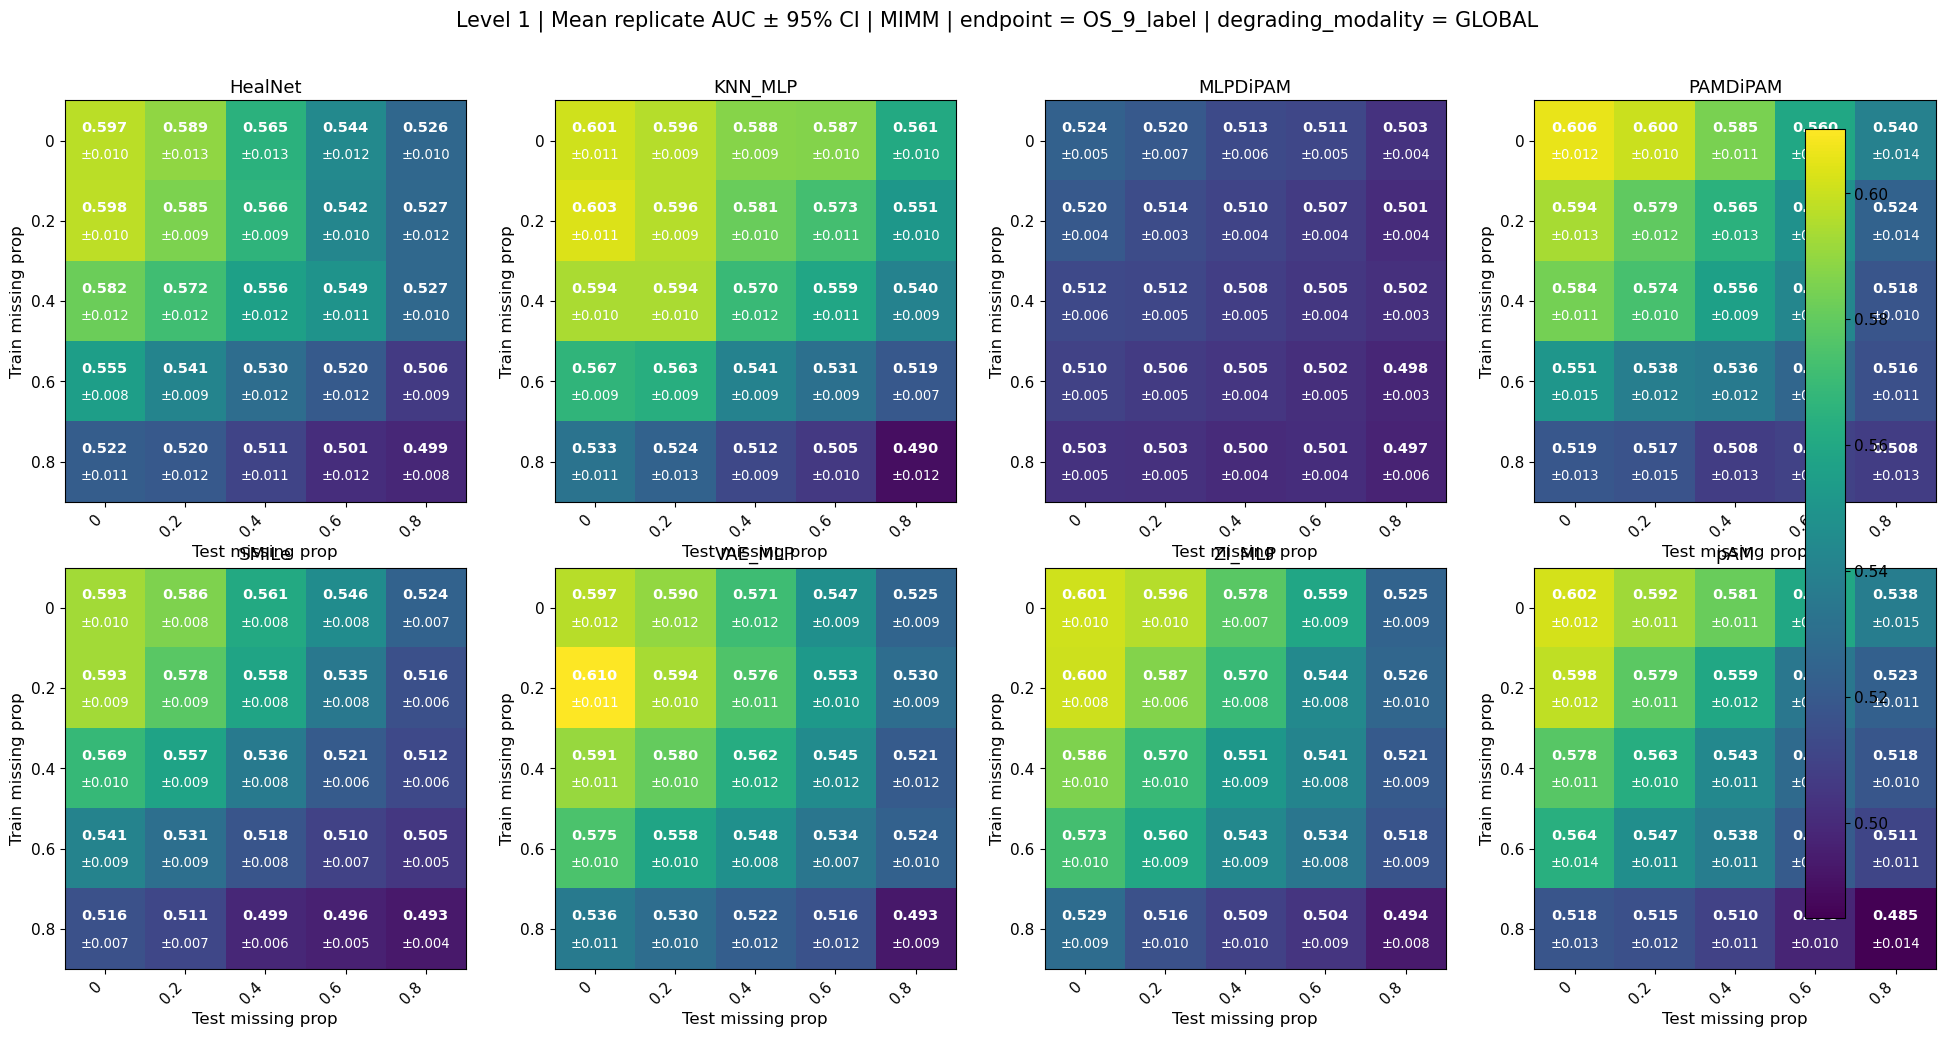

,model_name,train_missing_prop,test_missing_prop,n_replicates,mean_auc,ci_lower,ci_upper,ci_half_width,n_bootstrap_valid,std_auc
0,HealNet,0.0,0.0,25,0.597141,0.586621,0.607523,0.010451,2000,0.027082
1,HealNet,0.0,0.2,25,0.589105,0.576523,0.601688,0.012582,2000,0.032009
2,HealNet,0.0,0.4,25,0.564943,0.552164,0.578787,0.013312,2000,0.035077
3,HealNet,0.0,0.6,25,0.543909,0.531635,0.556426,0.012395,2000,0.032397
4,HealNet,0.0,0.8,25,0.526481,0.516460,0.536266,0.009903,2000,0.026648


In [13]:
level1_summary_df = compute_level1_summary(
    replicate_auc_df=replicate_auc_df,
    n_bootstrap=N_BOOTSTRAP,
    confidence=BOOTSTRAP_CONFIDENCE,
    random_seed=BOOTSTRAP_RANDOM_SEED,
)

level1_path = OUTPUT_DIR / 'level1_replicate_auc_summary.csv'
level1_summary_df.to_csv(level1_path, index=False)
print('Saved:', level1_path)
print('Level 1 rows:', len(level1_summary_df))

if HAVE_MPL:
    plot_level1_auc_heatmaps(
        level1_summary_df,
        title=f'Level 1 | Mean replicate AUC ± 95% CI | {DATASET_NAME} | endpoint = {LABEL_NAME} | degrading_modality = {TRAIN_MISSING_LOCATION}',
    )
else:
    print('Matplotlib not available; skipping level 1 heatmap plot.')

level1_summary_df.head()


Saved: /Users/marcalbesa/Desktop/TFM/git_exp/methods/analysis/statistical_tests_outputs/MIMM_OS_9_label/global/level2_winner_vs_runner_up.csv
Level 2 rows: 25


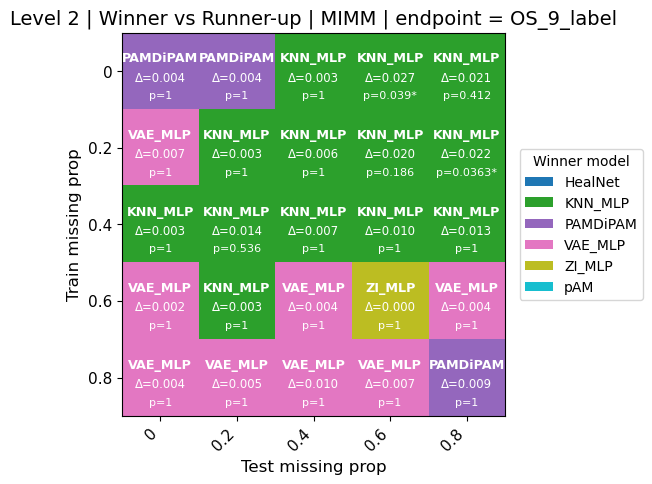

,train_missing_prop,test_missing_prop,winner_model,runner_up_model,winner_mean_auc,runner_up_mean_auc,delta_mean_auc,ci_lower,ci_upper,p_value,wilcoxon_statistic,n_replicates,n_bootstrap_valid,p_value_holm,significant_holm_0p05
0,0.0,0.0,PAMDiPAM,pAM,0.606212,0.601813,0.004398,-0.011187,0.020105,0.633827,144.0,25,2000,1.000000,False
1,0.0,0.2,PAMDiPAM,KNN_MLP,0.600177,0.596110,0.004066,-0.009669,0.017937,0.633827,144.0,25,2000,1.000000,False
2,0.0,0.4,KNN_MLP,PAMDiPAM,0.587595,0.584744,0.002851,-0.011291,0.017687,1.000000,162.0,25,2000,1.000000,False
3,0.0,0.6,KNN_MLP,PAMDiPAM,0.586793,0.559675,0.027117,0.012184,0.042359,0.001625,50.0,25,2000,0.039009,True
4,0.0,0.8,KNN_MLP,PAMDiPAM,0.560856,0.539670,0.021186,0.006288,0.036721,0.018745,76.0,25,2000,0.412384,False


In [14]:
level2_pairwise_df = compute_level2_pairwise_tests(
    level1_df=level1_summary_df,
    replicate_auc_df=replicate_auc_df,
)
level2_plot_df = select_level2_significant_plot_pairs(level2_pairwise_df)

level2_pairwise_path = OUTPUT_DIR / 'level2_pairwise_wilcoxon_fdr.csv'
level2_plot_path = OUTPUT_DIR / 'level2_significant_pairs_for_plot.csv'
level2_pairwise_df.to_csv(level2_pairwise_path, index=False)
level2_plot_df.to_csv(level2_plot_path, index=False)
print('Saved:', level2_pairwise_path)
print('Saved:', level2_plot_path)
print('Level 2 pairwise rows:', len(level2_pairwise_df))
print('Level 2 significant rows:', int(level2_pairwise_df['significant_fdr_0p05'].sum()) if not level2_pairwise_df.empty else 0)
print('Level 2 plotted cells:', len(level2_plot_df))

if HAVE_MPL:
    plot_level2_significant_pairs_heatmap(
        level2_plot_df,
        title=f'Level 2 | Significant Pairwise Wilcoxon + FDR | {DATASET_NAME} | endpoint = {LABEL_NAME}',
    )
else:
    print('Matplotlib not available; skipping level 2 significant-pair heatmap plot.')

level2_pairwise_df.head()
